In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from keras.models import load_model
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    auc,
    roc_curve,
    roc_auc_score,
    classification_report,
    precision_recall_curve,
    brier_score_loss,
)
import matplotlib.pyplot as plt

In [2]:
def evaluate_model(model, test_X, test_y, threshold):
    prob_y = model.predict(test_X)
    pred_y = np.where(prob_y >= threshold, 1, 0)
    print(roc_auc_score(test_y, prob_y))
    print(classification_report(test_y, pred_y))

In [3]:
strategy = "hypophetversion2"
model_path = Path(
    "../../model/260320_001228_hypophetversion2/inceptiontime.model.keras"
)
test_path = Path("../../data/mover/06.train_val_test")

In [4]:
X = np.load(test_path / f"mover_{strategy}_test_X.npy")
y = np.load(test_path / f"mover_{strategy}_test_y.npy")
print(X.shape, (y == 1).sum(), (y == 0).sum())

(47005, 3000) 8130 38875


In [5]:
loaded_model = load_model(model_path)

2026-03-20 16:17:39.122696: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Max
2026-03-20 16:17:39.122726: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-03-20 16:17:39.122731: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2026-03-20 16:17:39.122746: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-20 16:17:39.122756: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [6]:
y_prob = loaded_model.predict(X)

   7/1469 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step   

2026-03-20 16:17:39.614830: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1469/1469 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step


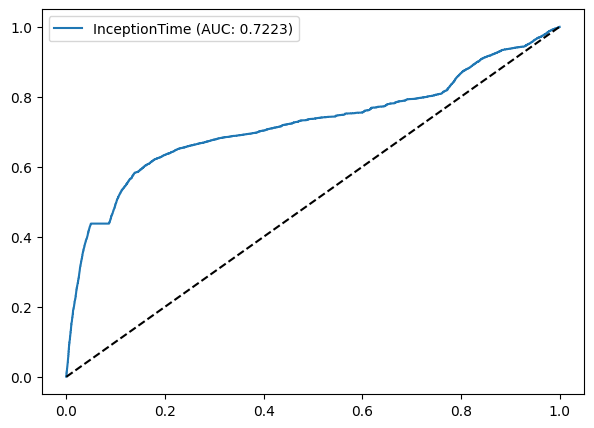

In [10]:
# auroc
fpr, tpr, thr = roc_curve(y, y_prob)
auroc = auc(fpr, tpr)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"InceptionTime (AUC: {auroc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="black")
plt.legend()
plt.show()

In [35]:
# classification
y_pred = np.where(y_prob < 0.6, 0, 1)
print("Threshold: 0.6")
print(classification_report(y, y_pred))

Threshold: 0.6
              precision    recall  f1-score   support

         0.0       0.91      0.82      0.86     38875
         1.0       0.41      0.62      0.50      8130

    accuracy                           0.78     47005
   macro avg       0.66      0.72      0.68     47005
weighted avg       0.83      0.78      0.80     47005



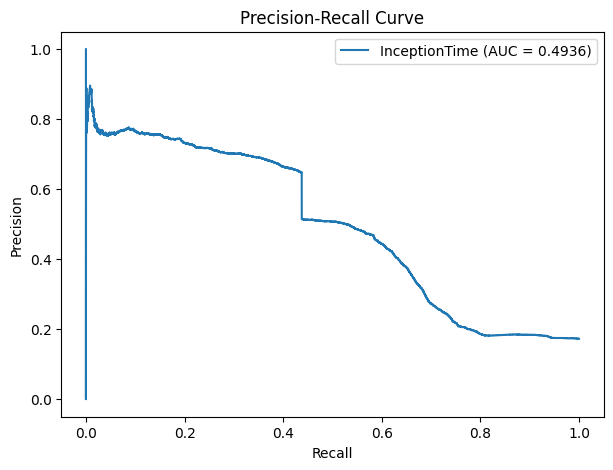

In [20]:
# prauc
prec, recall, prthr = precision_recall_curve(y, y_prob)
prauc = auc(recall, prec)
plt.figure(figsize=(7, 5))
plt.plot(recall, prec, label=f"InceptionTime (AUC = {prauc:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

In [ ]:
# DCA
dca_result = dca(
    data=pd.DataFrame(
        {
            "outcome": rand_y.reshape(-1),
            "hatib et al": acumen_probs.reshape(-1),
            "moghadam et al": moghadam_probs.reshape(-1),
            "hwang et al": asan_probs.reshape(-1),
            "proposed": hypophet_probs.reshape(-1),
        }
    ),
    outcome="outcome",
    modelnames=["hatib et al", "moghadam et al", "hwang et al", "proposed"],
)
thresholds = np.linspace(0, 1, 101)[1:]
acumen_cic = np.array([calc_cic(rand_y, acumen_probs, t) for t in thresholds])

plt.figure(figsize=(5, 4))
plot_graphs(
    plot_df=dca_result.query("model.isin(['hatib et al', 'all', 'none'])"),
    color_names=("black", "red", "blue"),
    linestyles=("--", "-", "-"),
    y_limits=(-0.1, 0.4),
    file_name="resource/dca_hatib.png",
)

fig, axs = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
axs[0][0].plot(
    thresholds, acumen_cic[:, 0], label="Number of high risk", color="red"
)
axs[0][0].plot(
    thresholds,
    acumen_cic[:, 1],
    label="Number of high risk with event",
    color="blue",
    linestyle="--",
)
axs[0][0].set_xlabel("Threshold Probability")
axs[0][0].set_ylabel("Number high risk (out of 1000)")
axs[0][0].set_title("Hatib et al")
axs[0][0].legend()

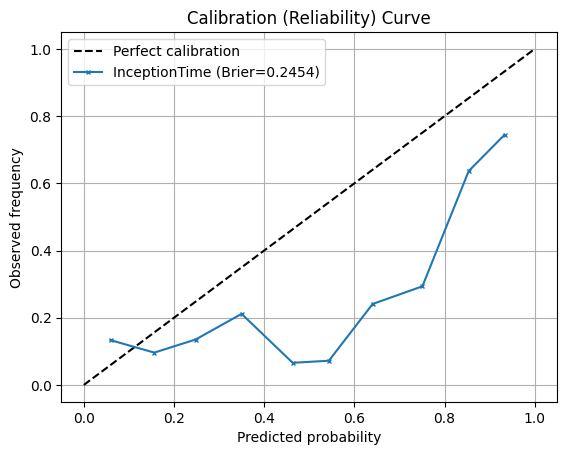

In [ ]:
# calibraion
bs = brier_score_loss(y, y_prob)
frac_pos, mean_pred = calibration_curve(y, y_prob, n_bins=10)
plt.figure()
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
plt.plot(
    mean_pred, frac_pos, "x-", label=f"InceptionTime (Brier={bs:.4f})", markersize=3
)
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.legend()
plt.grid(True)
plt.title("Calibration (Reliability) Curve")
plt.show()